# Best-Worst Method (BWM) - weight elicitation

**From: Alexander** - this notebook uses his `Scripts/BWM.py` as written (imported, not changed).

BWM turns a stakeholder's simple comparisons into criteria weights. This is what Q2 needs: there we
had to guess the weights, here we compute them properly.

### Requirements - Gurobi

`Scripts/BWM.py` solves a small optimisation with the **Gurobi** solver. Install it into your
environment (it is a normal Python package, no separate download):
```
pip install gurobipy
```
The free restricted licence that ships with `gurobipy` already solves this small model - no account,
no activation, no key needed. (It only matters for very large models, which this is not.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../Scripts")   # so we can import Alexander's function
from BWM import BWM

CRIT = ["pv", "daylight", "compactness", "fsi"]   # criteria order (indices 0,1,2,3)

### What the method asks the stakeholder

1. Which criterion is **most important** (best) and **least important** (worst)?
2. **Best-to-others** (`Ab`): how many times the best criterion beats each one, on a 1-9 scale.
3. **Others-to-worst** (`Aw`): how many times each criterion beats the worst one, 1-9.

BWM then finds the weights that fit those answers as closely as possible.

### Example: the client (values FSI most, daylight least)

In [2]:
# best = FSI (index 3),  worst = daylight (index 1)
Ab = np.array([2, 6, 3, 1])   # FSI is 2x PV, 6x daylight, 3x compactness, 1x itself
Aw = np.array([3, 1, 2, 6])   # PV 3x daylight, daylight 1x, compactness 2x, FSI 6x daylight

# show the inputs as a readable table
pd.DataFrame({"best-to-others (Ab)": Ab, "others-to-worst (Aw)": Aw}, index=CRIT)

,best-to-others (Ab),others-to-worst (Aw)
pv,2,3
daylight,6,1
compactness,3,2
fsi,1,6


In [3]:
# run Alexander's BWM
weights = BWM(Ab, Aw, b=3, w=1)          # b = best index, w = worst index
w = pd.Series(weights, index=CRIT).round(3)
w

Restricted license - for non-production use only - expires 2027-11-29


pv             0.250
daylight       0.083
compactness    0.167
fsi            0.500
dtype: float64

FSI comes out highest and daylight lowest - exactly what the client said. The weights sum to 1.

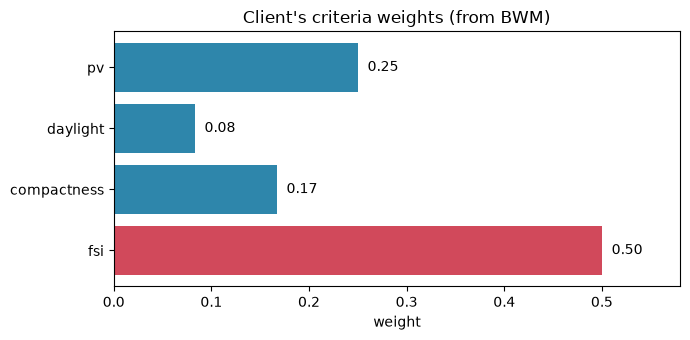

In [4]:
# visualise the weights
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#2e86ab' if c != w.idxmax() else '#d1495b' for c in w.index]
ax.barh(w.index[::-1], w.values[::-1], color=colors[::-1])
for i, v in enumerate(w.values[::-1]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)
ax.set_xlim(0, w.max() + 0.08)
ax.set_xlabel("weight")
ax.set_title("Client's criteria weights (from BWM)")
plt.tight_layout()
plt.savefig("../figures/bwm_client_weights.png", dpi=120, bbox_inches="tight")
plt.show()

### A second stakeholder, to see the weights change

The engineering team values compactness most and FSI least. Same method, different answers.

In [5]:
# best = compactness (index 2),  worst = fsi (index 3)
Ab_eng = np.array([3, 2, 1, 6])   # compactness vs [pv, daylight, comp, fsi]
Aw_eng = np.array([2, 3, 6, 1])   # each vs fsi
w_eng = pd.Series(BWM(Ab_eng, Aw_eng, b=2, w=3), index=CRIT).round(3)

compare = pd.DataFrame({"Client": w, "Engineering": w_eng})
compare

,Client,Engineering
pv,0.250,0.167
daylight,0.083,0.250
compactness,0.167,0.500
fsi,0.500,0.083


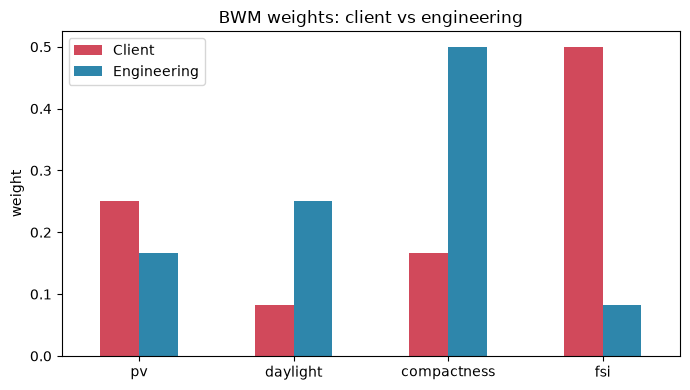

In [6]:
# both stakeholders side by side
compare.plot.bar(figsize=(7, 4), color=["#d1495b", "#2e86ab"])
plt.ylabel("weight"); plt.title("BWM weights: client vs engineering")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig("../figures/bwm_two_stakeholders.png", dpi=120, bbox_inches="tight")
plt.show()

### How this connects to Q2

In Q2 we guessed the stakeholder weights. BWM gives them properly: each stakeholder answers best /
worst + two comparison vectors, and we get their weights. Feed these weights into the Q2 weighted
sum and the recommendation is defensible - the weights came from elicitation, not from us.

To try another stakeholder, just change `Ab`, `Aw`, `b`, `w` above.